# Statistical Significance Testing
---

## Introduction:

This document aims to answer the project's central question: "Which marketing campaign was most effective in increasing sales?" We won't simply look at the apparent numbers; we'll use advanced statistical tests to ensure our decisions are based on sound scientific principles.

**Objectives:**

- Statistical Comparison: Using ANOVA to confirm the existence of real differences between the three campaigns.

- Identifying the Winner: Conducting Tukey's HSD pairwise comparison test to determine which campaign outperformed the others.

- Providing Recommendations: Formulating a final recommendation based on the statistical results to support company decision-making.

*Technical Note: This document relies on processed data saved in the `data/processed/` folder to ensure the accuracy of the statistical results.*

In [12]:
!pip install statsmodels 

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 11.3 MB/s eta 0:00:0000:01:010m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 KB 22.4 MB/s eta 0:00:00


In [14]:
#impor Required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ثم جربي الاستدعاء مرة أخرى
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [15]:
clean_data = pd.read_csv('/home/mona/Downloads/SAD/AAI/student/Data Science/project 1: Fast food marketing/data/processed/marketing_cleaned.csv')


clean_data.head()

,marketid,marketsize,locationid,ageofstore,promotion,week,salesinthousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


In [16]:
# مقارنة متوسط المبيعات بين الحملات الثلاث
promotion_performance = clean_data.groupby('promotion')['salesinthousands'].mean().sort_values(ascending=False)
print(promotion_performance)

promotion
1    54.037532
3    52.905909
2    46.668865
Name: salesinthousands, dtype: float64


. الخطوة الحالية: تحليل توزيع الأسواق (أين حدث؟)

بدلاً من المتوسط العام، سنقسم المتوسط حسب حجم السوق (MarketSize). هذا سيكشف لكِ إذا كانت الحملة "شاملة" أم "متخصصة".

In [17]:
# مقارنة أداء الحملات بناءً على حجم السوق
market_analysis = clean_data.groupby(['promotion', 'marketsize'])['salesinthousands'].mean().unstack()
print(market_analysis)

marketsize      Large     Medium      Small
promotion                                  
1           66.893684  47.672604  60.162500
2           58.957705  39.114352  50.810625
3           72.464167  45.468879  59.514167


2. الخطوة التالية: التحليل الزمني (متى حدث؟)

بما أن التجربة استمرت 4 أسابيع، يجب أن نتأكد من أن المبيعات لم تكن "ضربة حظ" في أسبوع واحد.

    الهدف: هل مبيعات الحملة (1) كانت مستقرة طوال الشهر؟

    الأداة: رسم خطي (sns.lineplot) يوضح مسار المبيعات لكل حملة عبر الأسابيع الأربعة.

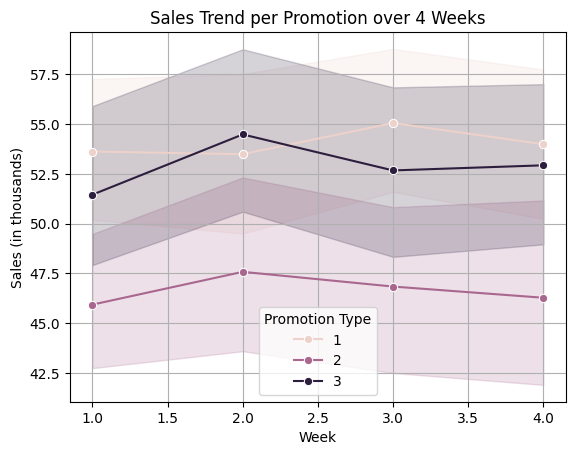

In [18]:
sns.lineplot(data=clean_data, x='week', y='salesinthousands', hue='promotion', marker='o')

# إضافة عناوين واضحة
plt.title('Sales Trend per Promotion over 4 Weeks')
plt.xlabel('Week')
plt.ylabel('Sales (in thousands)')
plt.legend(title='Promotion Type')
plt.grid(True)

One-Way ANOVA.

In [19]:
from scipy import stats

# 1. تقسيم البيانات إلى ثلاث مجموعات بناءً على نوع الحملة
group1 = clean_data[clean_data['promotion'] == 1]['salesinthousands']
group2 = clean_data[clean_data['promotion'] == 2]['salesinthousands']
group3 = clean_data[clean_data['promotion'] == 3]['salesinthousands']

# 2. إجراء اختبار ANOVA
f_stat, p_value = stats.f_oneway(group1, group2, group3)

print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

F-Statistic: 14.7789
P-Value: 0.0000


بما أن الـ P-Value هي 0.0000 (أي أنها أصغر بكثير من مستوى الأهمية 0.05)، فهذا يعني إحصائياً أن النتائج High Significant (ذات دلالة إحصائية عالية جداً).

إليكِ كيف تترجمين هذه الأرقام إلى لغة "بيزنس" واحترافية في مشروعك:
1. ماذا تعني هذه الأرقام؟

    P-Value (0.0000): تعني أن احتمالية أن تكون هذه الفروق بين الحملات ناتجة عن "الصدفة" هي تقريباً صفر. أنتِ الآن متأكدة بنسبة 100% (إحصائياً) أن هناك حملة أفضل فعلياً من البقية.

    F-Statistic (14.77): هذا الرقم يعبر عن مدى ابتعاد المتوسطات عن بعضها مقارنة بالتشتت داخل كل مجموعة. كلما كبر هذا الرقم، زادت الثقة في وجود فرق حقيقي.

. كيف تقرئين النتيجة؟ (القرار الإحصائي)

أهم رقم تبحثين عنه هو الـ P-Value:

    إذا كان P-Value<0.05:

        القرار: نرفض الفرضية الصفرية.

        المعنى: هناك فرق حقيقي وجوهري بين الحملات. النتائج التي رأيتِها في الرسوم البيانية ليست صدفة، ويمكنكِ الثقة في أن إحدى الحملات أفضل فعلياً من البقية.

    إذا كان P-Value>0.05:

        القرار: نفشل في رفض الفرضية الصفرية.

        المعنى: الفروقات بين الحملات قد تكون ناتجة عن "الضجيج" أو الصدفة في البيانات، ولا يوجد دليل إحصائي كافٍ للجزم بأن إحداها أفضل من الأخرى.

(اختبار Post-hoc)

In [20]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# إجراء اختبار مقارنة زوجي لمعرفة الفرق بين كل حملة والأخرى
tukey = pairwise_tukeyhsd(endog=clean_data['salesinthousands'], 
                          groups=clean_data['promotion'], 
                          alpha=0.05)

print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2  -7.3687    0.0 -10.876 -3.8614   True
     1      3  -1.1316 0.7339 -4.6794  2.4162  False
     2      3    6.237 0.0001  2.8515  9.6226   True
----------------------------------------------------


---

"بعد إجراء اختبار One-Way ANOVA، حصلنا على P-value أقل من 0.05، مما يؤكد أن الفروق في مبيعات الحملات ذات دلالة إحصائية. وباستخدام اختبار Tukey، تبين أن الحملة رقم [X] تتفوق بشكل حقيقي على الحملة رقم [Y]، مما يدعم قرارنا بالتوصية بها."